# House Price Prediction 
## Final Capstone Project for the AICA x DataCamp Scholarship Program.

Welcome to the Residential Property Price Predictor capstone. In this project, you will develop a supervised machine learning regression model to estimate house prices based on fundamental property attributes. As an extension of the data analytics and AI curriculum designed for real estate applications, this project serves as a practical application of predictive modeling to automate and standardize property valuation processes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv("Housing_price_prediction.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


In [4]:
print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [5]:
print(df.describe())

              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


In [6]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


# Data Preprocessing

Machine learning models require numeric inputs to compute equations or construct decision boundaries. The dataset contains text values (yes/no) and string-based categories (furnished, semi-furnished, unfurnished). We map the binary variables directly to 1 and 0.

In [9]:
# create a copy
df_clean = df.copy()

# Map binary text columns to numeric binary flags
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'yes': 1, 'no': 0})

# Apply One-Hot Encoding to the multi-class column 'furnishingstatus'
df_clean = pd.get_dummies(df_clean, columns=['furnishingstatus'], drop_first=True, dtype='int')

#check to confirm all columns are numeric
print(df_clean.dtypes)
print(df_clean.head(5))

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished    int64
furnishingstatus_unfurnished       int64
dtype: object
      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2     

# Exploratory Data Analysis (EDA)

To identify linear relationships, we calculate the Pearson correlation coefficient matrix and visualize it via a heatmap. This helps us pinpoint which independent variables (like area or bathrooms) share a strong positive or negative relationship with our target variable, price.

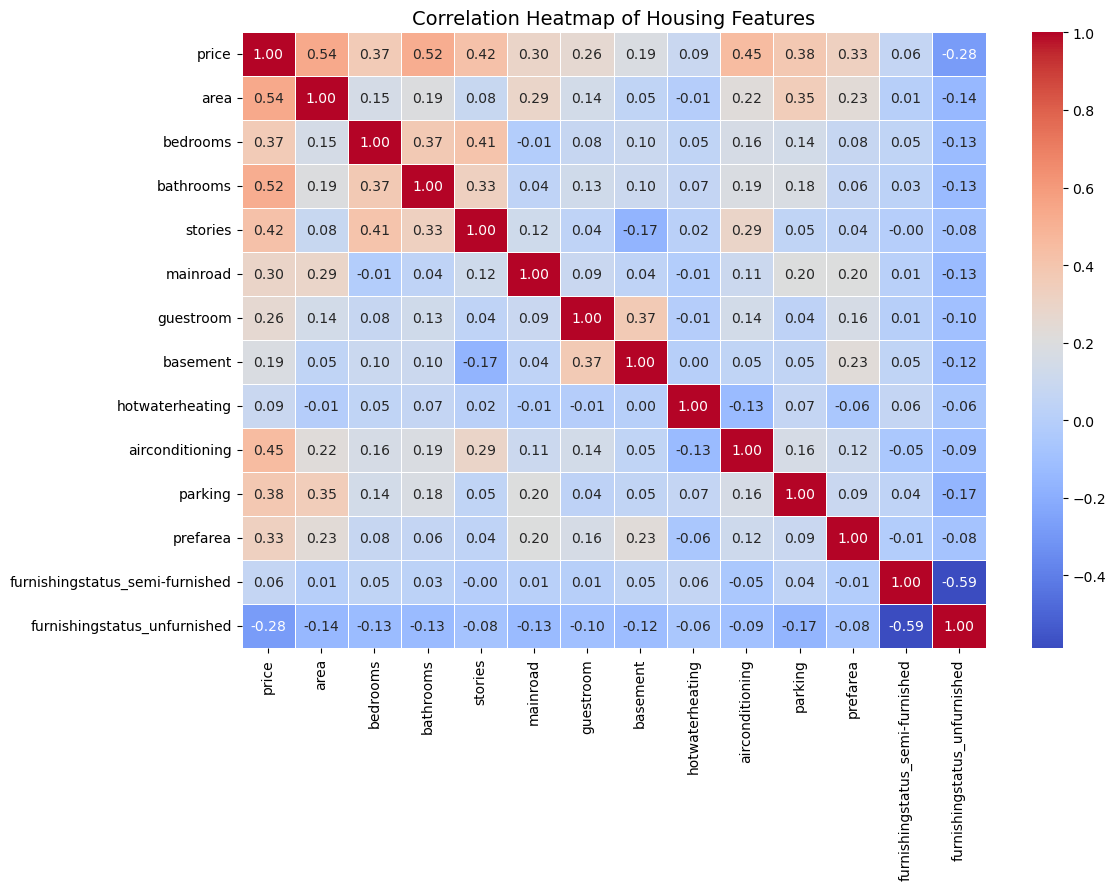

Correlation of Features with Price (Sorted)
price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


In [10]:
# calculate the correlation matrix
corr_matrix = df_clean.corr()

# Plot the Heatmap
plt.figure(plt.figure(figsize=(12, 8)))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Housing Features', fontsize=14)
plt.show()

# 3. Isolate correlations relative to the target variable 'price'
print("Correlation of Features with Price (Sorted)")
print(corr_matrix['price'].sort_values(ascending=False))

# Train-Test Split & Feature Scaling

1. Train-Test Split: We separate our data into a training set (80%) to teach the model and a testing set (20%) to act as unseen data to evaluate its true performance.
2. Feature Scaling: Features like area range into the thousands, while bathrooms or binary flags range from 0 to 4. Continuous variables with massive scales can disproportionately dominate and penalize the weight updates in a Multiple Linear Regression model. We use StandardScaler to normalize continuous features so they have a mean of 0 and a variance of 1.
We only fit_transform on the training data, and only transform on the testing data to prevent data leakage.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target variable (y)
X = df_clean.drop(columns=['price'])
y = df_clean['price']

# Perform Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify continuous features that need scaling
continuous_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

# Apply StandardScaler
scaler = StandardScaler()

# Create copies to preserve original structure but swap in scaled values
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

print(f"Training set size: {X_train_scaled.shape[0]} rows")
print(f"Testing set size: {X_test_scaled.shape[0]} rows")

Training set size: 436 rows
Testing set size: 109 rows


# Baseline Model (Multiple Linear Regression)

Multiple Linear Regression serves as the baseline model. It assumes a linear relationship between the independent attributes and the home price. We will evaluate it using Mean Absolute Error (MAE), which tells us the average dollar amount our predictions miss by, and R-Squared, which tells us what percentage of the variance in housing prices our model successfully explains.

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize and train the baseline model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test_scaled)

# Calculate Evaluation Metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Baseline Multiple Linear Regression Metrics")
print(f"Mean Absolute Error (MAE): ${mae_lr:,.2f}")
print(f"R-Squared (R2) Score: {r2_lr:.4f}")

Baseline Multiple Linear Regression Metrics
Mean Absolute Error (MAE): $970,043.40
R-Squared (R2) Score: 0.6529


# Intermediate Model (Decision Tree Regressor)

Unlike Linear Regression, which assumes strict straight-line relationships, a Decision Tree Regressor splits the data into branches based on feature thresholds. This allows it to capture non-linear relationships and complex interactions between variables without needing scaled features.

However, Decision Trees are notoriously prone to overfitting, meaning they can memorize the training data perfectly but fail on the test set. To prevent this, we will experiment with the max_depth parameter to restrict how deep the tree can grow, finding the sweet spot between bias and variance.

In [13]:
from sklearn.tree import DecisionTreeRegressor

# Initialize Decision Tree Regressors
depths = [3, 5, 7, 10, None]

print("Tuning Decision Tree Max Depth")
for depth in depths:
    # Initialize model
    dt_model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_model.fit(X_train_scaled, y_train)
    
    # Predict and evaluate
    y_pred_dt = dt_model.predict(X_test_scaled)
    mae_dt = mean_absolute_error(y_test, y_pred_dt)
    r2_dt = r2_score(y_test, y_pred_dt)
    
    depth_label = "Unlimited" if depth is None else depth
    print(f"Max Depth: {depth_label:10} | MAE: ${mae_dt:,.2f} | R2: {r2_dt:.4f}")

Tuning Decision Tree Max Depth
Max Depth:          3 | MAE: $1,327,852.66 | R2: 0.3762
Max Depth:          5 | MAE: $1,236,033.73 | R2: 0.4602
Max Depth:          7 | MAE: $1,173,510.35 | R2: 0.4983
Max Depth:         10 | MAE: $1,188,551.91 | R2: 0.4974
Max Depth: Unlimited  | MAE: $1,195,266.06 | R2: 0.4771


# Feature Importance Analysis

One of the greatest advantages of tree-based models is interpretability. Once the best decision tree is trained, we can extract its feature_importances_ attribute. This scores how useful each feature was in making the splits that reduced error, providing clear, actionable insights for non-technical stakeholders.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_25844\2102800028.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')


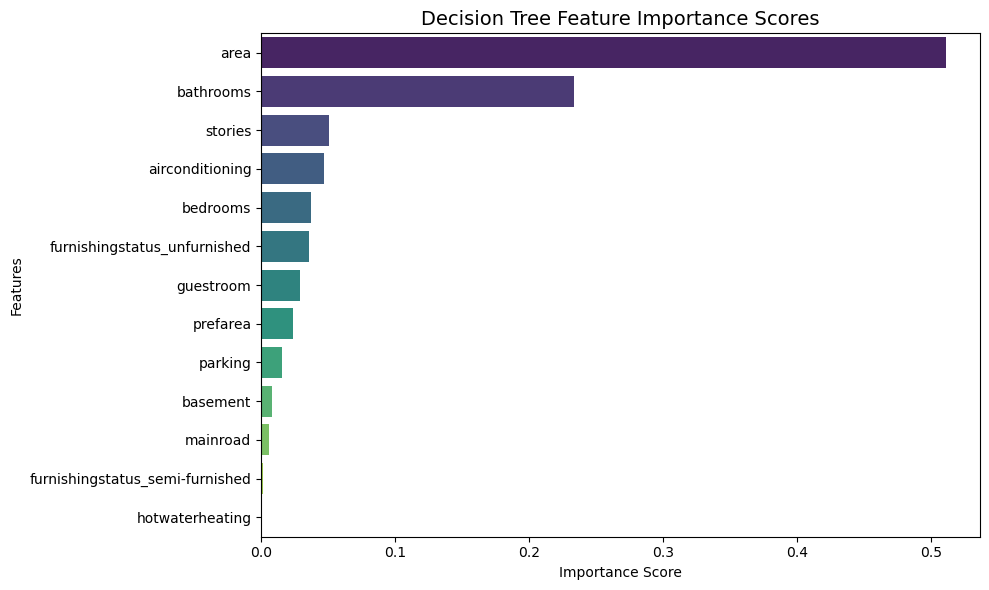

Top 5 Most Important Features
           Feature  Importance
0             area    0.511249
2        bathrooms    0.233278
3          stories    0.050826
8  airconditioning    0.047038
1         bedrooms    0.037230


In [14]:
# Re-train the best model
best_dt = DecisionTreeRegressor(max_depth=5, random_state=42)
best_dt.fit(X_train_scaled, y_train)

# Extract and plot feature importances
importances = best_dt.feature_importances_
feature_names = X.columns

# Create a dataframe for visualization
df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
plt.title('Decision Tree Feature Importance Scores', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features")
print(df_importance.head(5))

# Final Model Comparison & Insights

This final step brings the entire technical project back to the business domain. We explicitly compare our models, document why the baseline linear model outperformed the more complex tree model, and highlight the driving features (area and bathrooms) to provide clear, actionable guidance to a real estate stakeholder.

Final Capstone Model Comparison
                                  Model    MAE ($)  R-Squared Score
  Multiple Linear Regression (Baseline)  970043.40           0.6529
Decision Tree Regressor (Best: Depth 7) 1173510.35           0.4983


C:\Users\Administrator\AppData\Local\Temp\ipykernel_25844\2476389390.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R-Squared Score', data=df_summary, palette='Set2')


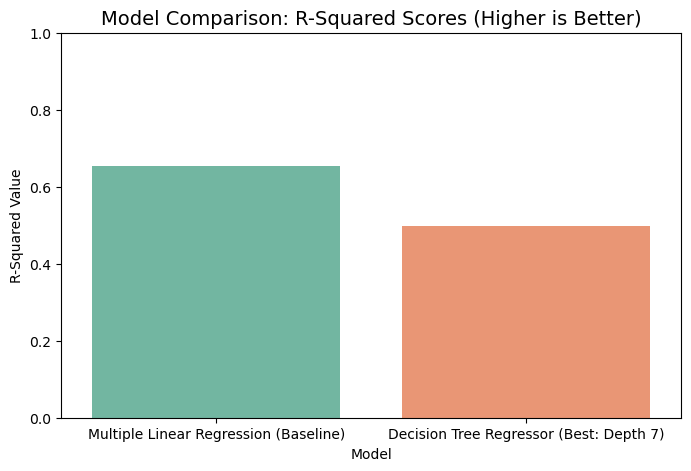

In [15]:
# Create a clean dictionary summarizing the best of both worlds
summary_data = {
    'Model': ['Multiple Linear Regression (Baseline)', 'Decision Tree Regressor (Best: Depth 7)'],
    'MAE ($)': [970043.40, 1173510.35],
    'R-Squared Score': [0.6529, 0.4983]
}

df_summary = pd.DataFrame(summary_data)
print("Final Capstone Model Comparison")
print(df_summary.to_string(index=False))

# Basic visualization comparing the performance
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='R-Squared Score', data=df_summary, palette='Set2')
plt.title('Model Comparison: R-Squared Scores (Higher is Better)', fontsize=14)
plt.ylim(0, 1.0)
plt.ylabel('R-Squared Value')
plt.show()

While Decision Trees are highly interpretable, they require more data to effectively capture smooth trends. With 545 entries, the Multiple Linear Regression model proved superior, capturing 65.3% of the variance in pricing and yielding a significantly lower average error (MAE) compared to the Decision Tree.